In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

In [16]:
!pip install emoji

In [17]:

import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
nltk.download('stopwords', quiet=True)

True

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
path = "/content/drive/MyDrive/TER/Data/reddit/brute_merged_emotyc.csv"
pathout = "/content/drive/MyDrive/TER/exports/brute_merged_emotyc_oneshot.csv"


In [20]:

CSV_PATH  = path  # chemin vers ton fichier
TEXT_COL  = 'full_text'            # nom de la colonne texte
LABEL_COL = 'Perspective_label'           # nom de la colonne label (0/1 ou haineux/non-haineux)
SEP       = ','               # séparateur CSV
ENCODING  = 'utf-8'           # encodage (essaie 'latin-1' si erreur)
# ─────────────────────────────────────────────

df = pd.read_csv(CSV_PATH, sep=SEP, encoding=ENCODING)
print(len(df))

1271


In [21]:


stemmer = SnowballStemmer('french')




def normaliser_repetitions(text):
    pattern_repeat = re.compile(r'([a-zA-ZÀ-ÿ])\1{2,}', re.IGNORECASE)
    return pattern_repeat.sub(r'\1', text)

# ── Pipeline principal ────────────────────────────────────────
def preprocess_tweet(text, stem=True):
    text = str(text)

    text = emoji.demojize(text, language='fr')

    text = text.lower()

    text = re.sub(r':([a-z_àâéèêëîïôùûüç]+):', r' \1 ', text)


    text = normaliser_repetitions(text)


    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)


    text = re.sub(r'@\w+', ' USER ', text)


    text = re.sub(r'#(\w+)', r' \1 ', text)


    text = re.sub(r"[^\w\s']", ' ', text)


    tokens = [t for t in text.split() if len(t) >= 2]


    if stem:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)



df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print(f'Après suppression doublons : {len(df):,} tweets')


df['text_clean_stemmed'] = df[TEXT_COL].apply(preprocess_tweet)
df['text_clean'] = df[TEXT_COL].apply(lambda x: preprocess_tweet(x, stem=False))


print(f'\n✅ Preprocessing terminé')
print(f'\n── Exemples ──')
for _, row in df.sample(5, random_state=42).iterrows():
    print(f'\n[Classe {row[LABEL_COL]}]')
    print(f'  AVANT : {row[TEXT_COL][:120]}')
    print(f'  APRÈS : {row["text_clean"][:120]}')

Après suppression doublons : 1,264 tweets

✅ Preprocessing terminé

── Exemples ──

[Classe 1]
  AVANT : La vf de la saison 3 de Black Lagoon est sympa aussi (j'aime beaucoup la comédienne qui double Levi) mais ouais, l'absen
  APRÈS : la vf de la saison de black lagoon est sympa aussi j'aime beaucoup la comédienne qui double levi mais ouais l'absence de

[Classe 0]
  AVANT : ah mais je m'en fou concrètement, dans mon cas précis : j'ai pas d'armes, je vis au 3ème étage d'un immeuble au centre v
  APRÈS : ah mais je m'en fou concrètement dans mon cas précis j'ai pas d'armes je vis au 3ème étage d'un immeuble au centre vile 

[Classe 0]
  AVANT : Best phto of him ever.
  APRÈS : best phto of him ever

[Classe 0]
  AVANT : Pour pas qu'on passe a travers la vitre... (Chose vue)
  APRÈS : pour pas qu'on passe travers la vitre chose vue

[Classe 1]
  AVANT : C’est même pas une tenue religieuse mais bon vu qu’apparemment faut parler sans savoir comme un fils de pute beh let’s g
  APRÈS : est 

In [22]:

print('Distribution des classes après nettoyage :')
print(df[LABEL_COL].value_counts())
print(f'\nTaille moyenne des tweets nettoyés :')
print(df['text_clean'].str.split().str.len().describe().round(1))

Distribution des classes après nettoyage :
Perspective_label
0    980
1    284
Name: count, dtype: int64

Taille moyenne des tweets nettoyés :
count    1264.0
mean       45.8
std        81.7
min         1.0
25%        11.0
50%        22.0
75%        50.0
max      1143.0
Name: text_clean, dtype: float64


In [23]:
df.columns

Index(['user', 'text', 'title', 'Perspective_label', 'full_text',
       'avec_emo_comportementale', 'avec_cat_fierte', 'avec_emo_complexe',
       'avec_cat_colere', 'avec_cat_joie', 'avec_cat_autre',
       'avec_cat_tristesse', 'avec_emo', 'avec_cat_surprise',
       'avec_emo_designee', 'avec_emo_base', 'avec_cat_peur',
       'avec_cat_admiration', 'avec_emo_montree', 'avec_emo_suggeree',
       'avec_cat_embarras', 'found', 'text_clean_stemmed', 'text_clean'],
      dtype='object')

In [24]:
CATEGORIELLES_OH = ['avec_cat_joie',
       'avec_cat_admiration', 'avec_cat_tristesse', 'avec_cat_surprise',
       'avec_emo_comportementale', 'avec_cat_autre', 'avec_emo_designee',
       'avec_emo', 'avec_emo_base', 'avec_emo_suggeree', 'avec_cat_embarras',
       'avec_cat_colere', 'avec_cat_fierte', 'avec_emo_complexe',
       'avec_emo_montree', 'avec_cat_peur','found']  # tes colonnes déjà encodées

In [25]:
print('Occurrences of 1 in each categorical column:')
for col in CATEGORIELLES_OH:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())

Occurrences of 1 in each categorical column:

--- avec_cat_joie ---
avec_cat_joie
0    1177
1      87
Name: count, dtype: int64

--- avec_cat_admiration ---
avec_cat_admiration
0    1108
1     156
Name: count, dtype: int64

--- avec_cat_tristesse ---
avec_cat_tristesse
0    1189
1      75
Name: count, dtype: int64

--- avec_cat_surprise ---
avec_cat_surprise
0    1209
1      55
Name: count, dtype: int64

--- avec_emo_comportementale ---
avec_emo_comportementale
0    1205
1      59
Name: count, dtype: int64

--- avec_cat_autre ---
avec_cat_autre
0    1257
1       7
Name: count, dtype: int64

--- avec_emo_designee ---
avec_emo_designee
0    1124
1     140
Name: count, dtype: int64

--- avec_emo ---
avec_emo
0    842
1    422
Name: count, dtype: int64

--- avec_emo_base ---
avec_emo_base
0    943
1    321
Name: count, dtype: int64

--- avec_emo_suggeree ---
avec_emo_suggeree
0    1113
1     151
Name: count, dtype: int64

--- avec_cat_embarras ---
avec_cat_embarras
0    1252
1      12
Name

In [26]:
df.to_csv(pathout, index=False)

In [27]:

CATEGORIELLES_OH = [
    col for col in CATEGORIELLES_OH
    if df[col].sum() > 10
]

══════════════════════════════════════════════════════════════════════
  CROSS-VALIDATION 5 FOLDS
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
  VERSION : SANS STEMMING
──────────────────────────────────────────────────────────────────────
  Modèle                      Accuracy   F1-macro  Précision     Recall
  ───────────────────────── ────────── ────────── ────────── ──────────
  Random Forest                  0.805     0.565      0.569      0.864  (±0.030)
  Naive Bayes                    0.794     0.611      0.599      0.703  (±0.046)
  SVM Linéaire                   0.823     0.683      0.657      0.778  (±0.027)
  Régression Logistique          0.789     0.496      0.530      0.893  (±0.022)

──────────────────────────────────────────────────────────────────────
  VERSION : AVEC STEMMING
──────────────────────────────────────────────────────────────────────
  Modèle                 

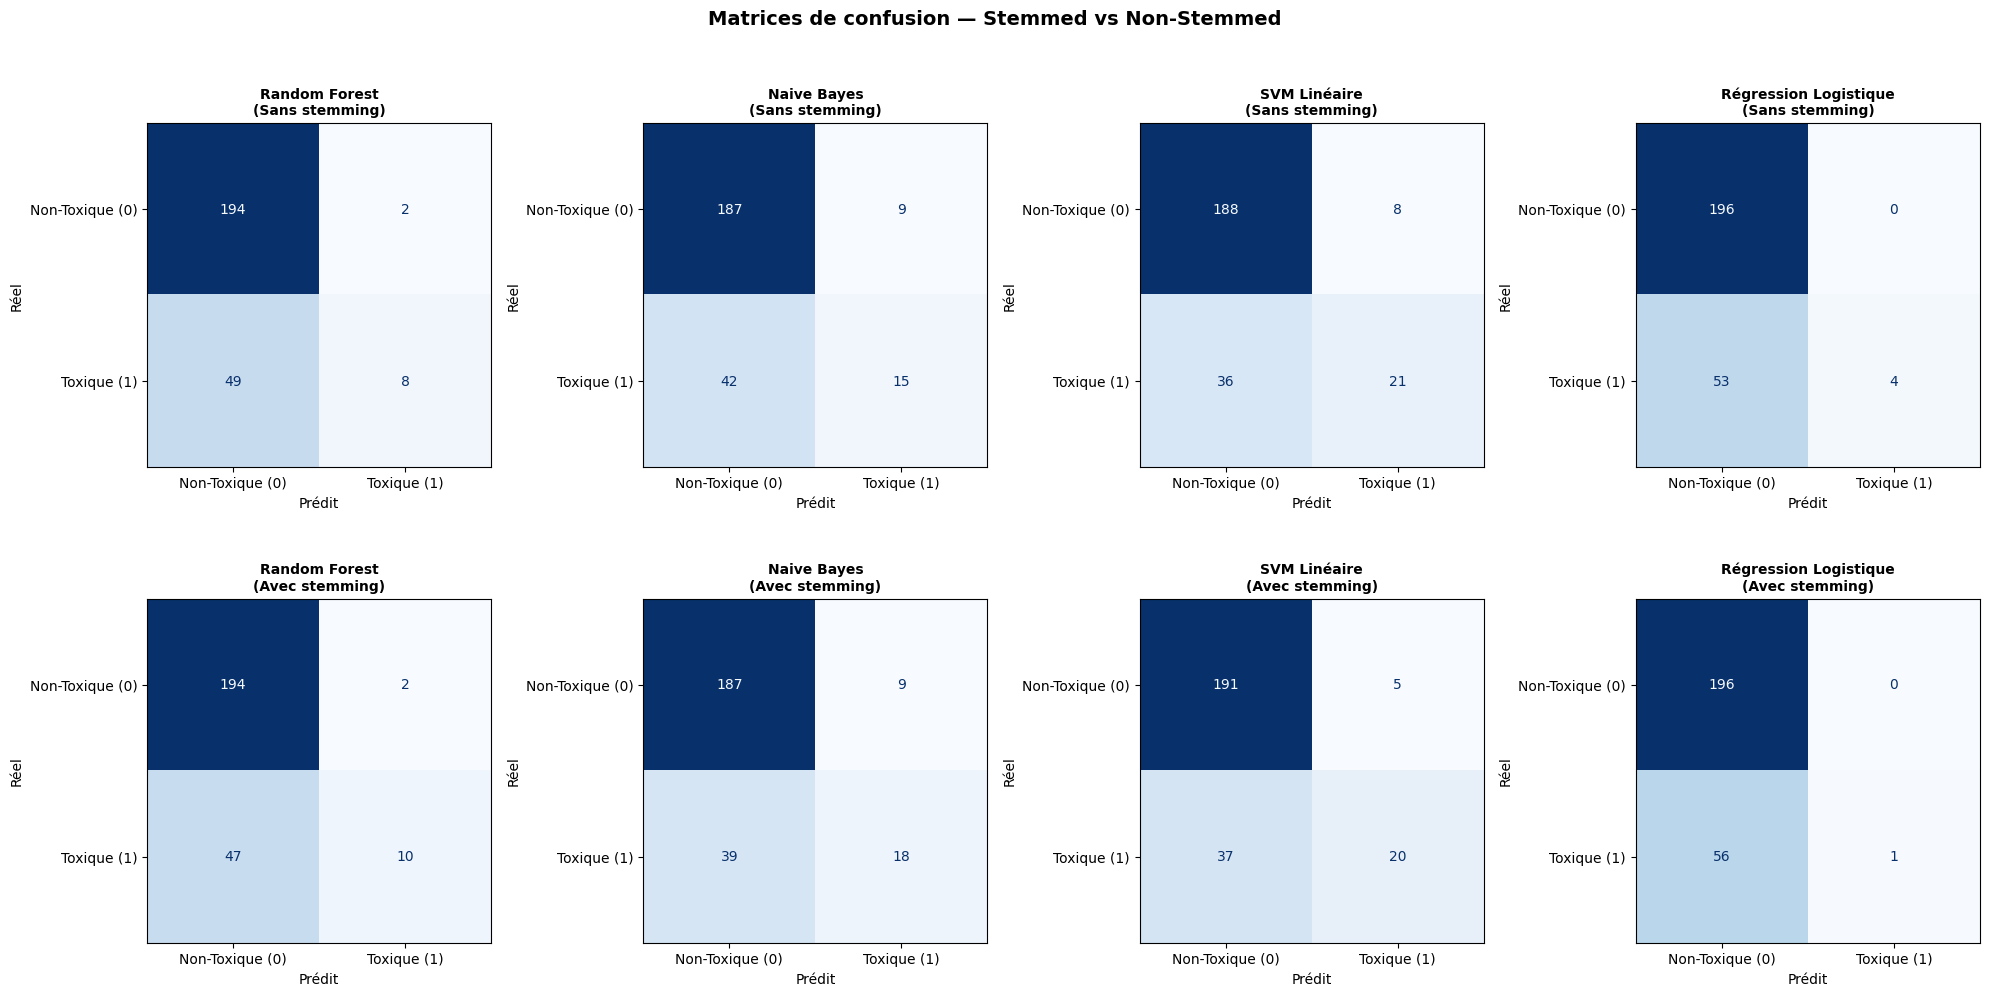

In [28]:


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier



VERSIONS = {
    'Sans stemming' : df[['text_clean'] + CATEGORIELLES_OH].rename(columns={'text_clean': 'text'}),
    'Avec stemming' : df[['text_clean_stemmed'] + CATEGORIELLES_OH].rename(columns={'text_clean_stemmed': 'text'}),
}

MODELES = {
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'          : ComplementNB(),
    'SVM Linéaire'         : LinearSVC(max_iter=1500, random_state=42),
    'Régression Logistique': LogisticRegression(max_iter=1500, random_state=42),
}

METRIQUES = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

y = df[LABEL_COL]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(clf):
    preprocessor = ColumnTransformer([
        ('text', TfidfVectorizer(
            ngram_range=(1,2),
            sublinear_tf=True,
            max_features=50000,
            min_df=2
        ), 'text'),

        ('cat', 'passthrough', CATEGORIELLES_OH)
    ])

    return Pipeline([
        ('preprocess', preprocessor),
        ('clf', clf)
    ])

print('═'*70)
print('  CROSS-VALIDATION 5 FOLDS')
print('═'*70)

tous_resultats = {}

for version_nom, X in VERSIONS.items():
    print(f'\n{"─"*70}')
    print(f'  VERSION : {version_nom.upper()}')
    print(f'{"─"*70}')
    print(f'  {"Modèle":<25} {"Accuracy":>10} {"F1-macro":>10} {"Précision":>10} {"Recall":>10}')
    print(f'  {"─"*25} {"─"*10} {"─"*10} {"─"*10} {"─"*10}')

    for nom_clf, clf in MODELES.items():
        pipeline = make_pipeline(clf)
        scores = cross_validate(pipeline, X, y, cv=cv, scoring=METRIQUES)
        tous_resultats[(version_nom, nom_clf)] = scores

        acc = scores['test_accuracy'].mean()
        f1  = scores['test_f1_macro'].mean()
        pre = scores['test_precision_macro'].mean()
        rec = scores['test_recall_macro'].mean()
        std = scores['test_f1_macro'].std()

        print(f'  {nom_clf:<25} {acc:>10.3f} {f1:>9.3f} {rec:>10.3f} {pre:>10.3f}  (±{std:.3f})')


print(f'\n\n{"═"*70}')
print('  MATRICES DE CONFUSION — Ensemble test final (80/20)')
print('═'*70)

noms_classes = ['Non-Toxique (0)', 'Toxique (1)']
n_versions   = len(VERSIONS)
n_modeles    = len(MODELES)

fig, axes = plt.subplots(
    n_versions, n_modeles,
    figsize=(5 * n_modeles, 5 * n_versions)
)
fig.suptitle('Matrices de confusion — Stemmed vs Non-Stemmed', fontsize=14, fontweight='bold', y=1.01)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for j, (nom_clf, clf) in enumerate(MODELES.items()):
        pipeline = make_pipeline(clf)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)
        ax = axes[i][j]

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=noms_classes)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')

        ax.set_title(f'{nom_clf}\n({version_nom})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Prédit')
        ax.set_ylabel('Réel')

        # Rapport textuel
        print(f'\n── {nom_clf} | {version_nom} ──')
        print(classification_report(y_test, y_pred, target_names=noms_classes))

plt.tight_layout()
plt.show()

══════════════════════════════════════════════════════════════════════
  DIAGNOSTIC OVERFITTING / UNDERFITTING
══════════════════════════════════════════════════════════════════════

── Random Forest | Sans stemming ──
  F1 Train : 0.997
  F1 Test  : 0.561
  Gap      : 0.436

── Naive Bayes | Sans stemming ──
  F1 Train : 0.935
  F1 Test  : 0.625
  Gap      : 0.309

── SVM Linéaire | Sans stemming ──
  F1 Train : 0.997
  F1 Test  : 0.692
  Gap      : 0.305

── Régression Logistique | Sans stemming ──
  F1 Train : 0.679
  F1 Test  : 0.506
  Gap      : 0.173

── Random Forest | Avec stemming ──
  F1 Train : 0.997
  F1 Test  : 0.589
  Gap      : 0.408

── Naive Bayes | Avec stemming ──
  F1 Train : 0.941
  F1 Test  : 0.657
  Gap      : 0.283

── SVM Linéaire | Avec stemming ──
  F1 Train : 0.997
  F1 Test  : 0.694
  Gap      : 0.303

── Régression Logistique | Avec stemming ──
  F1 Train : 0.693
  F1 Test  : 0.455
  Gap      : 0.238


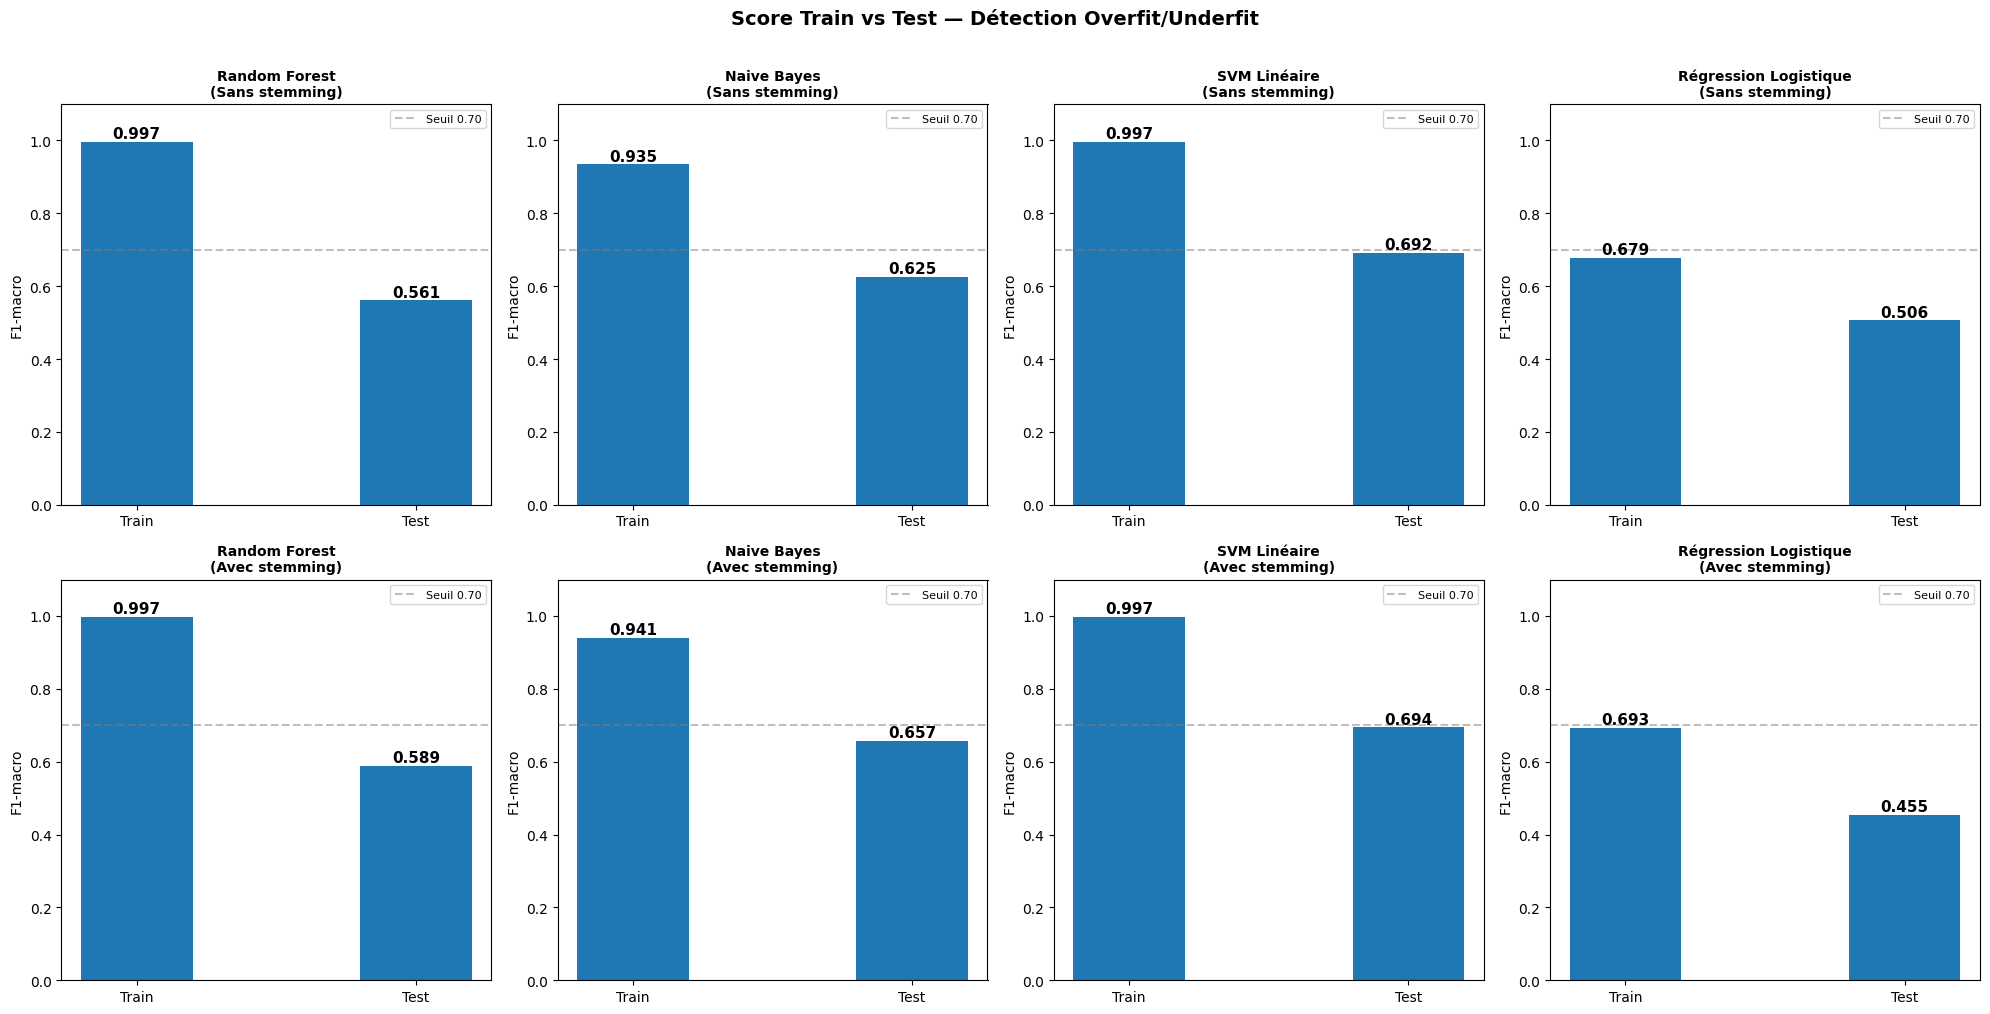

In [29]:


from sklearn.metrics import f1_score

print('═'*70)
print('  DIAGNOSTIC OVERFITTING / UNDERFITTING')
print('═'*70)

fig, axes = plt.subplots(n_versions, n_modeles, figsize=(5 * n_modeles, 5 * n_versions))
fig.suptitle('Score Train vs Test — Détection Overfit/Underfit', fontsize=14, fontweight='bold', y=1.01)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for j, (nom_clf, clf) in enumerate(MODELES.items()):
        pipeline = make_pipeline(clf)
        pipeline.fit(X_train, y_train)

        # Score directement sur train et test
        score_train = f1_score(y_train, pipeline.predict(X_train), average='macro')
        score_test  = f1_score(y_test,  pipeline.predict(X_test),  average='macro')
        gap         = score_train - score_test



        # ── Affichage texte ───────────────────────────────────
        print(f'\n── {nom_clf} | {version_nom} ──')
        print(f'  F1 Train : {score_train:.3f}')
        print(f'  F1 Test  : {score_test:.3f}')
        print(f'  Gap      : {gap:.3f}')


        # ── Graphique barres ──────────────────────────────────
        ax = axes[i][j]
        bars = ax.bar(['Train', 'Test'], [score_train, score_test],
                      width=0.4)

        for bar, val in zip(bars, [score_train, score_test]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

        ax.set_ylim(0, 1.1)
        ax.set_title(f'{nom_clf}\n({version_nom})', fontsize=10, fontweight='bold')
        ax.set_ylabel('F1-macro')
        ax.axhline(y=0.70, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.70')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

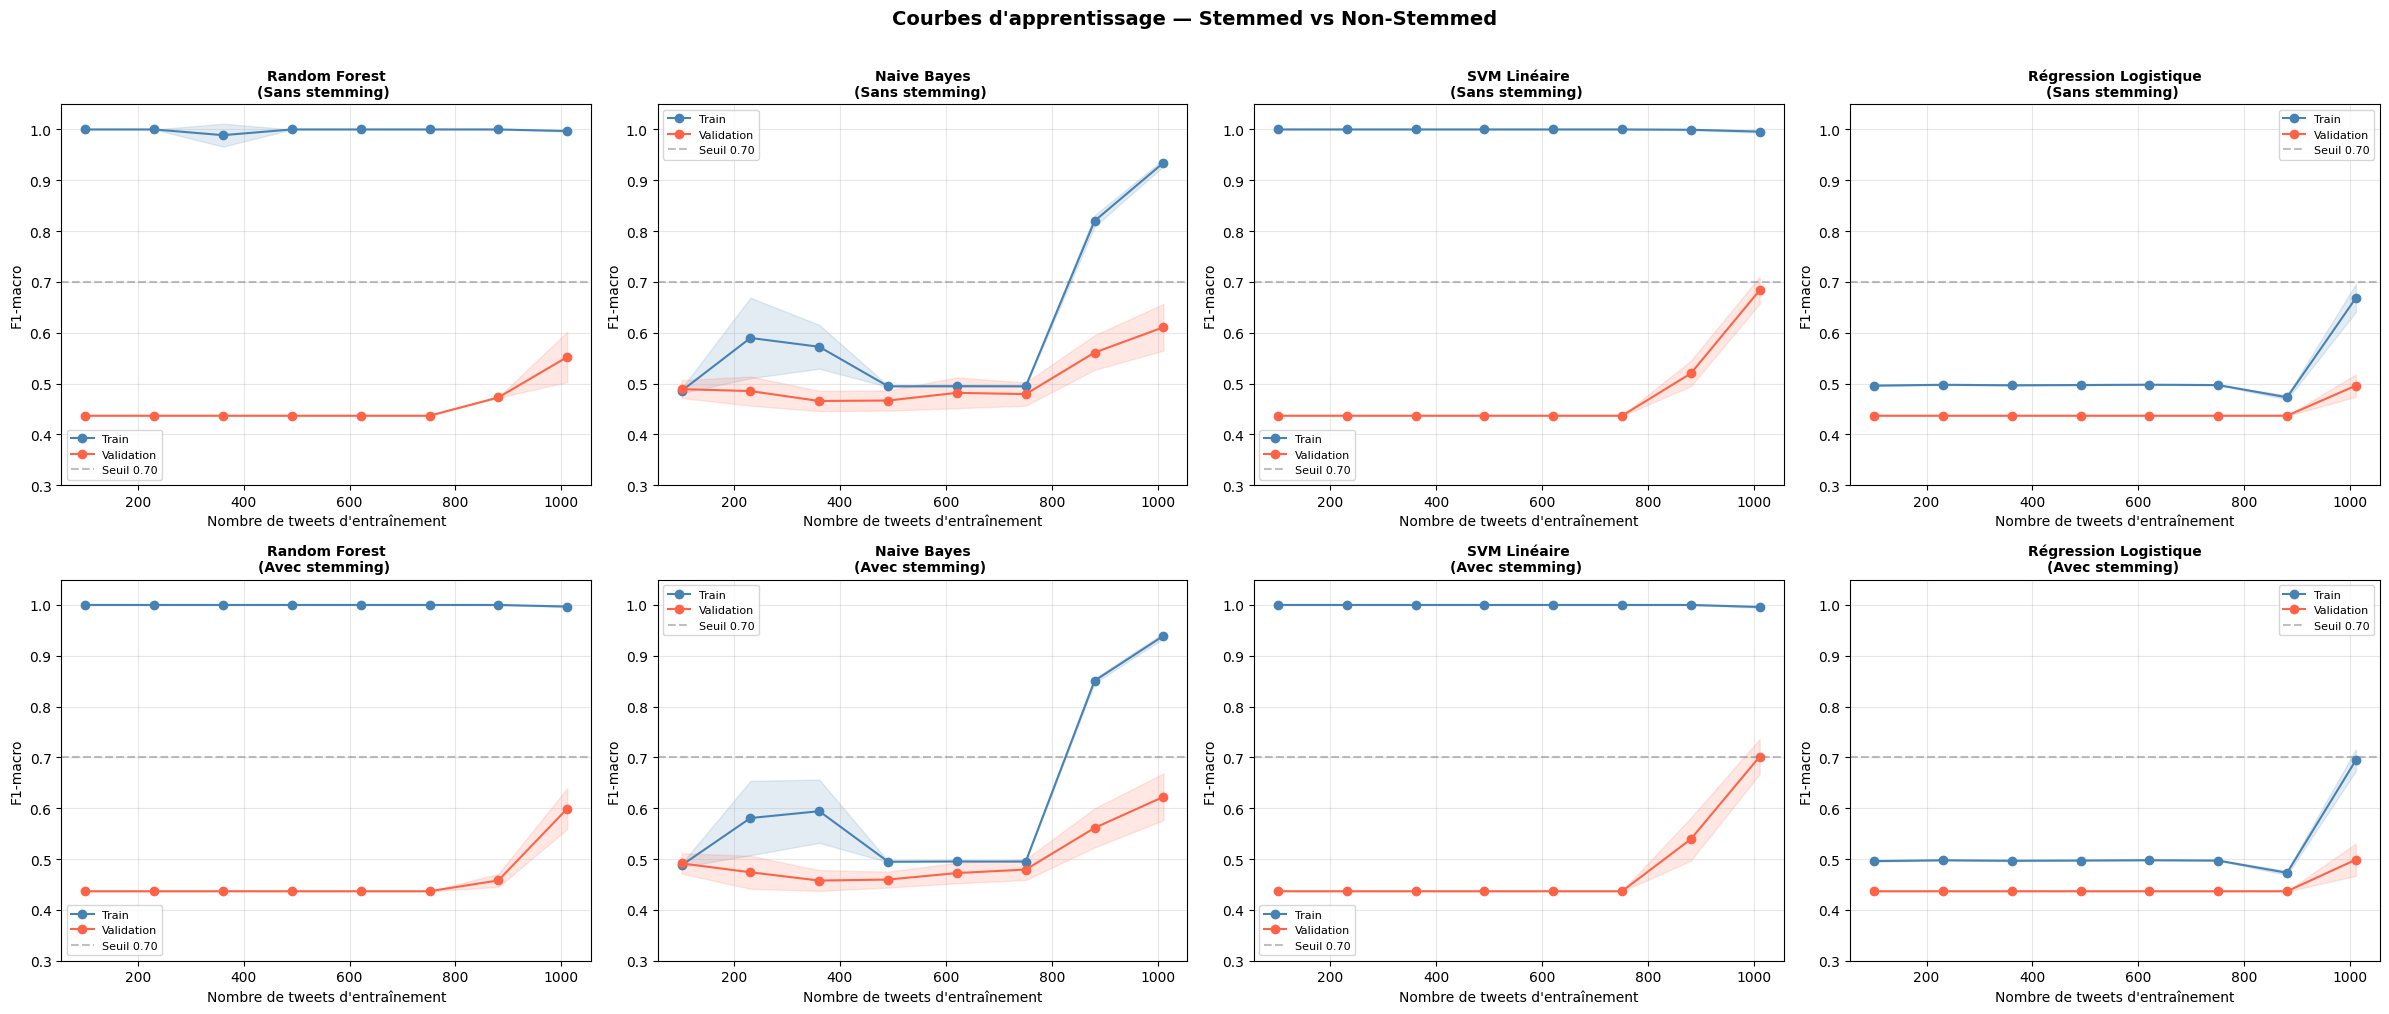

In [30]:


from sklearn.model_selection import learning_curve
n_versions = len(VERSIONS)
n_modeles  = len(MODELES)
fig, axes = plt.subplots(n_versions, n_modeles, figsize=(6 * n_modeles, 5 * n_versions))
fig.suptitle("Courbes d'apprentissage — Stemmed vs Non-Stemmed",
             fontsize=14, fontweight='bold', y=1.01)

train_sizes = np.linspace(0.1, 1.0, 8)

for i, (version_nom, X) in enumerate(VERSIONS.items()):
    for j, (nom_clf, clf) in enumerate(MODELES.items()):

        pipeline = make_pipeline(clf)

        train_sizes_abs, train_scores, val_scores = learning_curve(
            pipeline, X, y,
            train_sizes=train_sizes,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1_macro',
            n_jobs=-1
        )

        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1)
        val_std    = val_scores.std(axis=1)



        # ── Tracé ─────────────────────────────────────────────
        ax = axes[i][j]

        ax.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Train')
        ax.fill_between(train_sizes_abs,
                        train_mean - train_std,
                        train_mean + train_std,
                        alpha=0.15, color='steelblue')

        ax.plot(train_sizes_abs, val_mean, 'o-', color='tomato', label='Validation')
        ax.fill_between(train_sizes_abs,
                        val_mean - val_std,
                        val_mean + val_std,
                        alpha=0.15, color='tomato')

        ax.axhline(y=0.70, color='gray', linestyle='--', alpha=0.5, label='Seuil 0.70')
        ax.set_title(f'{nom_clf}\n({version_nom}) ', fontsize=10, fontweight='bold')
        ax.set_xlabel("Nombre de tweets d'entraînement")
        ax.set_ylabel('F1-macro')
        ax.set_ylim(0.3, 1.05)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
